# Task: To Build a classification model for predicting the income using Adult Census Income Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Exploratory Data Analysis

In [2]:
df = pd.read_csv('adultcensusincome.csv')
df.sample()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
26714,30,Private,324120,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,50,United-States,<=50K


In [3]:
df.info()
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
Number of duplicates: 24


In [4]:
df['age'].sort_values().unique()

array([17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 90])

In [5]:
df.drop_duplicates(inplace=True) # drop duplicates

In [6]:
for col in df.columns:
    num = (df[col] == '?').sum()
    print(f"{col} has {num} of '?' values")

age has 0 of '?' values
workclass has 1836 of '?' values
fnlwgt has 0 of '?' values
education has 0 of '?' values
education.num has 0 of '?' values
marital.status has 0 of '?' values
occupation has 1843 of '?' values
relationship has 0 of '?' values
race has 0 of '?' values
sex has 0 of '?' values
capital.gain has 0 of '?' values
capital.loss has 0 of '?' values
hours.per.week has 0 of '?' values
native.country has 582 of '?' values
income has 0 of '?' values


In [7]:
df = df.replace('?', 'unknown') # replace '?' with 'unknown'
df.reset_index(drop=True, inplace=True) # reset index after dropping duplicates
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  str  
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  str  
 4   education.num   32537 non-null  int64
 5   marital.status  32537 non-null  str  
 6   occupation      32537 non-null  str  
 7   relationship    32537 non-null  str  
 8   race            32537 non-null  str  
 9   sex             32537 non-null  str  
 10  capital.gain    32537 non-null  int64
 11  capital.loss    32537 non-null  int64
 12  hours.per.week  32537 non-null  int64
 13  native.country  32537 non-null  str  
 14  income          32537 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


### Univariate Analysis
#### Distribution of target variable: Income

In [8]:
income_distribution = df['income'].value_counts()
print(income_distribution)


income
<=50K    24698
>50K      7839
Name: count, dtype: int64


Income is divided into 2 categories

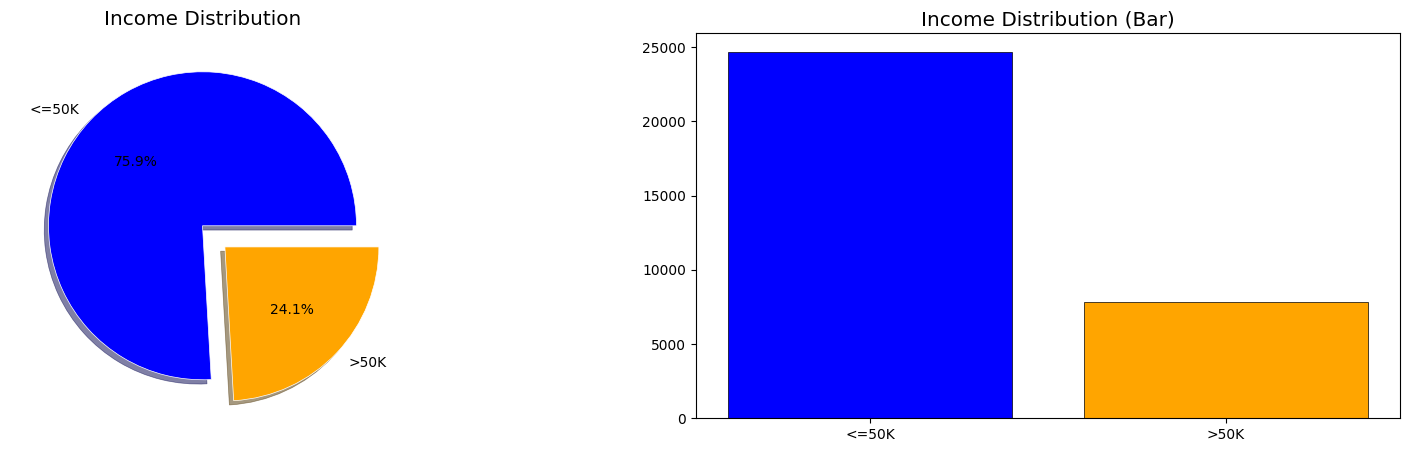

In [9]:
fig, ax = plt.subplots(1,2, figsize=(20,5))
plt.style.use('ggplot')
ax[0].pie(income_distribution, labels=income_distribution.index, autopct='%1.1f%%',
		  explode=(0, 0.20), shadow=True, wedgeprops={'edgecolor': 'white'}, colors=['blue', 'orange'])
ax[0].set_title('Income Distribution')

ax[1].bar(income_distribution.index, income_distribution.values, color=['blue', 'orange'], edgecolor='black')
ax[1].set_title('Income Distribution (Bar)')
plt.show()

There's approximately a 3:1 ratio imbalance between income categories

#### Distribution of Age

/tmp/ipykernel_74833/1683162208.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='education', order=df['education'].value_counts().index, palette='pastel', edgecolor='black', ax=ax[0][1])
/tmp/ipykernel_74833/1683162208.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='marital.status', palette='pastel', edgecolor='black', ax=ax[1][0])
/tmp/ipykernel_74833/1683162208.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='occupation', palette='pastel', edgecolor='black', ax=ax[1][1])


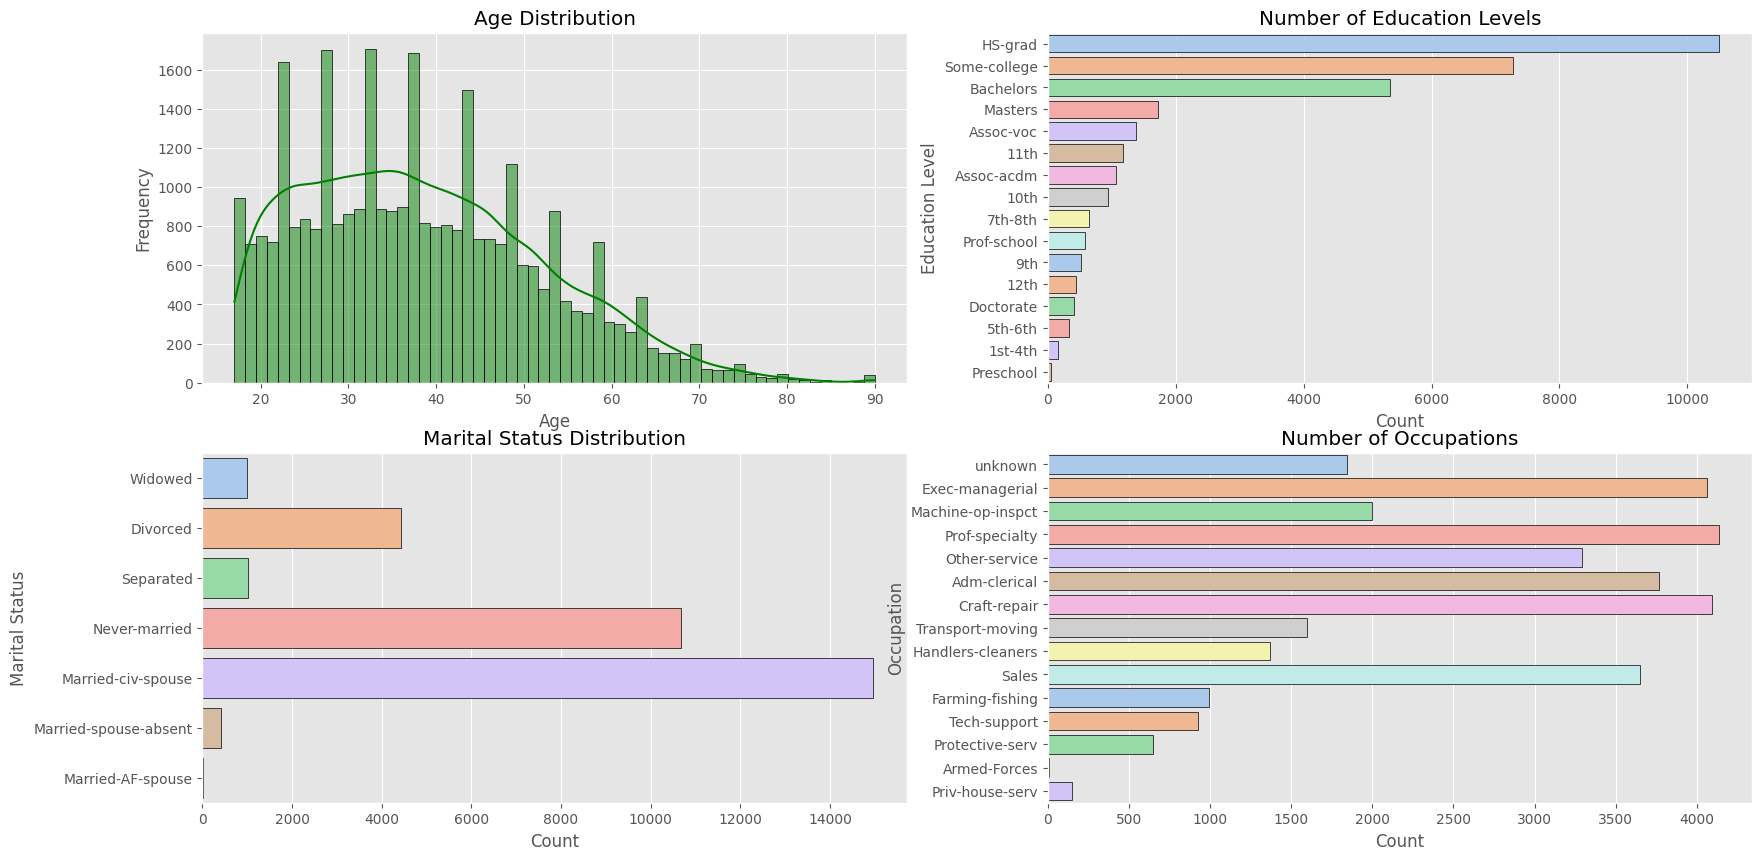

In [10]:
fig, ax = plt.subplots(2,2, figsize=(20,10))
plt.style.use('ggplot')
sns.histplot(df['age'], bins='auto', kde=True, color='green', edgecolor='black', ax=ax[0][0])
ax[0][0].set_title('Age Distribution')
ax[0][0].set_xlabel('Age')
ax[0][0].set_ylabel('Frequency')

sns.countplot(data=df, y='education', order=df['education'].value_counts().index, palette='pastel', edgecolor='black', ax=ax[0][1])
ax[0][1].set_title('Number of Education Levels')
ax[0][1].set_xlabel('Count')
ax[0][1].set_ylabel('Education Level')

sns.countplot(data=df, y='marital.status', palette='pastel', edgecolor='black', ax=ax[1][0])
ax[1][0].set_title('Marital Status Distribution')
ax[1][0].set_xlabel('Count')
ax[1][0].set_ylabel('Marital Status')

sns.countplot(data=df, y='occupation', palette='pastel', edgecolor='black', ax=ax[1][1])
ax[1][1].set_title('Number of Occupations')
ax[1][1].set_xlabel('Count')
ax[1][1].set_ylabel('Occupation')
plt.show()  

### Bivariate Analysis

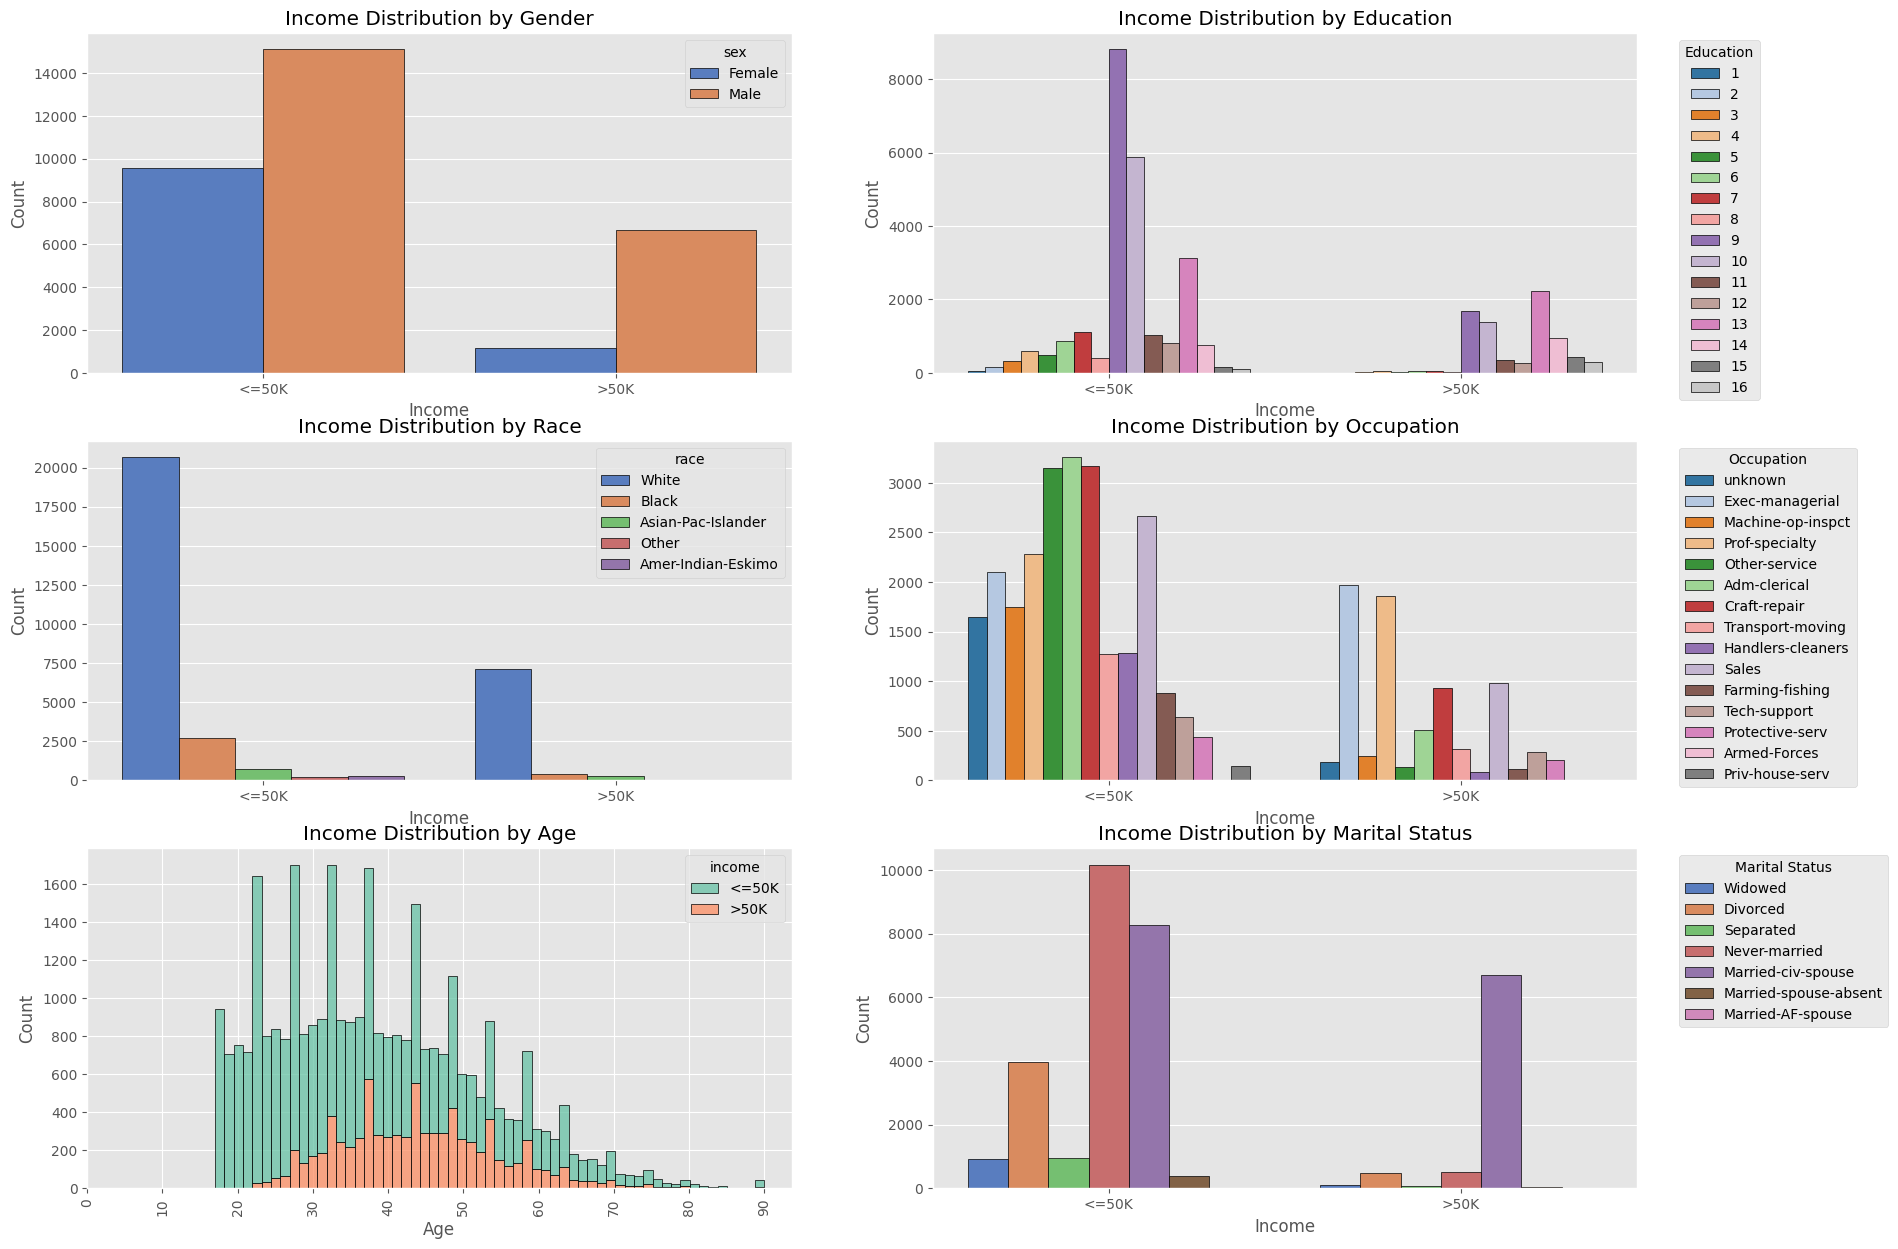

In [11]:
fig, ax = plt.subplots(3,2, figsize=(20,15))
plt.style.use('ggplot')
sns.countplot(data=df, x='income', hue='sex', palette='muted', edgecolor='black', ax=ax[0,0])
ax[0,0].set_title('Income Distribution by Gender')
ax[0,0].set_xlabel('Income')
ax[0,0].set_ylabel('Count')

sns.countplot(data=df, x='income', hue='education.num', palette='tab20', edgecolor='black', ax=ax[0,1])
ax[0,1].set_title('Income Distribution by Education')
ax[0,1].set_xlabel('Income')
ax[0,1].set_ylabel('Count')
ax[0,1].legend(title='Education', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.countplot(data=df, x='income', hue='race', palette='muted', edgecolor='black', ax=ax[1,0])
ax[1,0].set_title('Income Distribution by Race')
ax[1,0].set_xlabel('Income')
ax[1,0].set_ylabel('Count')

sns.countplot(data=df, x='income', hue='occupation', palette='tab20', edgecolor='black', ax=ax[1,1])
ax[1,1].set_title('Income Distribution by Occupation')
ax[1,1].set_xlabel('Income')
ax[1,1].set_ylabel('Count')
ax[1,1].legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.histplot(data=df, x='age', hue='income', palette='Set2', multiple='stack', edgecolor='black', ax=ax[2,0])
ax[2,0].set_title('Income Distribution by Age')
ax[2,0].set_xlabel('Age')
ax[2,0].set_ylabel('Count')
ax[2,0].set_xticks(range(0, 100, 10))
ax[2,0].set_xticklabels([str(x) for x in range(0, 100, 10)], rotation=90)

sns.countplot(data=df, x='income', hue='marital.status', palette='muted', edgecolor='black', ax=ax[2,1])
ax[2,1].set_title('Income Distribution by Marital Status')
ax[2,1].set_xlabel('Income')
ax[2,1].set_ylabel('Count')
ax[2,1].legend(title='Marital Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()  

In [12]:
cat = df.select_dtypes(include='object').columns

/tmp/ipykernel_74833/1166740012.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include='object').columns


In [13]:
label_encoders = {}
for col in cat:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [14]:
label_encoders

{'workclass': LabelEncoder(),
 'education': LabelEncoder(),
 'marital.status': LabelEncoder(),
 'occupation': LabelEncoder(),
 'relationship': LabelEncoder(),
 'race': LabelEncoder(),
 'sex': LabelEncoder(),
 'native.country': LabelEncoder(),
 'income': LabelEncoder()}

<Axes: >

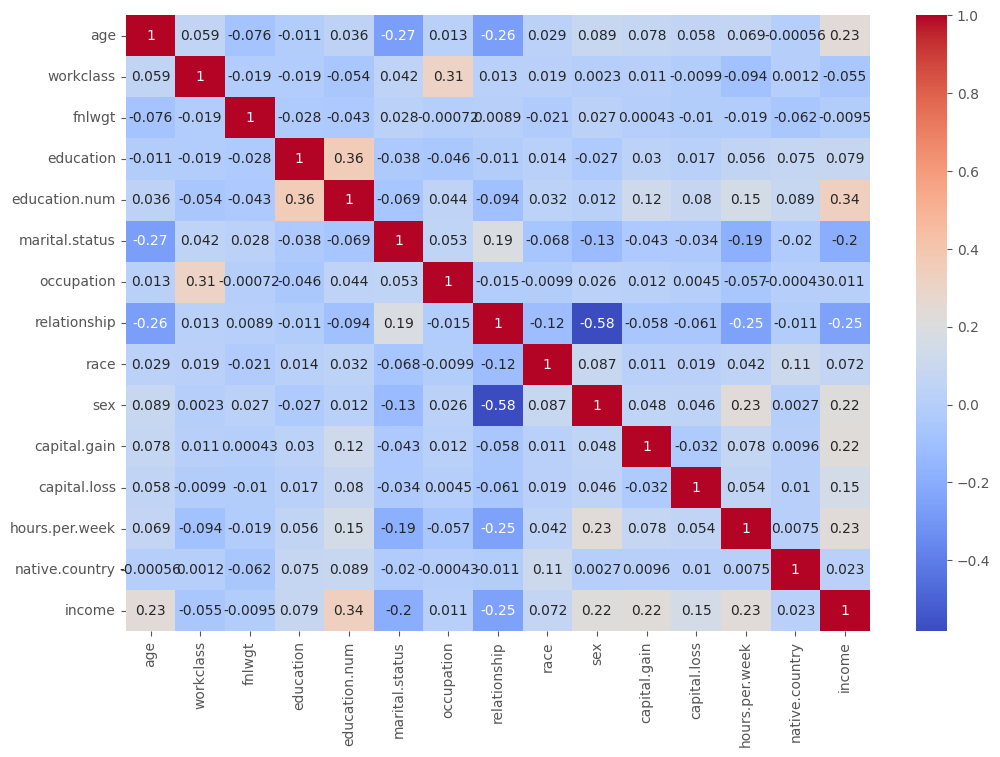

In [15]:
total_matrix = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(total_matrix, cmap='coolwarm', annot=True)

In [16]:
X = df.drop('income', axis=1)
y = df['income']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest f1 Score:", f1_score(y_test, y_pred))

Random Forest Accuracy: 0.8466502765826674
Random Forest f1 Score: 0.6829733163913596


Confusion Matrix:
[[4435  553]
 [ 445 1075]]


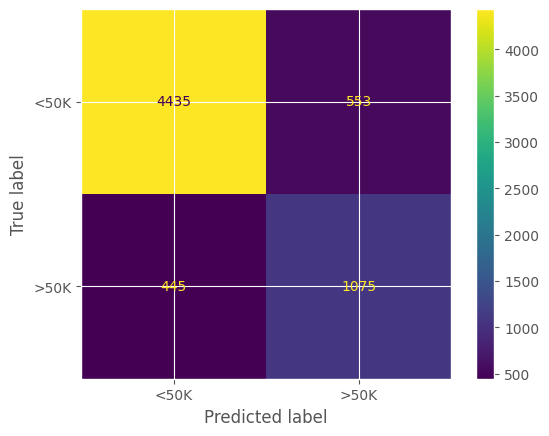

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()

In [22]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
param_dist = { 'n_estimators': randint(100, 500), 'max_depth': [None, 10, 20, 30, 40], 'min_samples_split': randint(2, 10), 'min_samples_leaf': randint(1, 5), 'max_features': randint(1, X_train.shape[1]) } 
random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), 
param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42) 
random_search.fit(X_train, y_train) 
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=40, max_features=5, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   5.5s
[CV] END max_depth=40, max_features=5, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   5.6s
[CV] END max_depth=40, max_features=5, min_samples_leaf=3, min_samples_split=3, n_estimators=314; total time=   6.0s
[CV] END max_depth=20, max_features=11, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   6.4s
[CV] END max_depth=30, max_features=13, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   6.8s
[CV] END max_depth=30, max_features=13, min_samples_leaf=3, min_samples_split=4, n_estimators=171; total time=   6.9s
[CV] END max_depth=20, max_features=11, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   6.9s
[CV] END max_depth=20, max_features=11, min_samples_leaf=4, min_samples_split=6, n_estimators=199; total time=   6.8

Random Forest Accuracy: 0.8411186232329441
Random Forest f1 Score: 0.6942637492607925
Classification Report:
              precision    recall  f1-score   support

        <50K       0.93      0.86      0.89      4988
        >50K       0.63      0.77      0.69      1520

    accuracy                           0.84      6508
   macro avg       0.78      0.82      0.79      6508
weighted avg       0.86      0.84      0.85      6508

Confusion Matrix:
[[4300  688]
 [ 346 1174]]


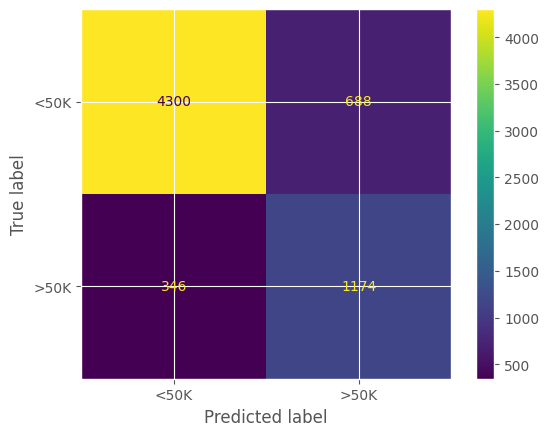

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(**random_search.best_params_, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest f1 Score:", f1_score(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["<50K", ">50K"]))

# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["<50K", ">50K"])
# display matrix
cm_display.plot()
plt.show()
